In [ ]:
from langchain_core.runnables import RunnableConfig
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from operator import add

# 상태 예시
class State(TypedDict):
    count: int
    messages: list[str]

# 리듀서 예시 (add가 리듀서)
class State(TypedDict):
    count:int
    messages: Annotated[list[str],add]

# 노드 예시
builder = StateGraph(dict)# 상태 그래프 선언
def my_node(state:dict, config: RunnableConfig): # 노드로 사용할 함수 정의
    print("In node: ", config['configurable']['user_id'])
    return {"results":f"Hello, {state['input']}!"}

def my_other_node(state:dict):
    return state # 상태를 그대로 반환

# 그래프에 노드 추가
builder.add_node("my_node", my_node)
builder.add_node("other_node",my_other_node)

# START 노드
graph.add_edge(START,'node_a') # START 노드가 실행된 후, node_a로 상태가 전달

# END 노드
graph.add_edge("node_a",END) # noda_a가 실행된 후 그래프가 종료

# 일반 엣지
graph.add_edge("node_a","node_b") # node_a 작업이 끝난 후, node_b 실행

# 조건부 에지
graph.add_conditional_edges("node_a", routing_function, {True:"node_b", False:"node_c"}) # routing_function이 node_a 다음으로 어떤 노드를 사용할 지 결정하는 함수, 해당 함수의 반환값이 True면 node_b를 False면 node_c를 실행

# 진입 지점: 그래프가 시작될 때 처음 실행할 노드 명시, 주로 START라는 가상의 노드를 사용하여 그래프의 첫 실행 지점을 설정
graph.add_edge(START, 'node_a')

# 조건부 진입 지점: 사용자의 입력이나 외부 조건에 따라 그래프 실행의 첫 번째 노드를 동적으로 결정
graph.add_conditional_edges(START, routing_function, {True:"node_b", False:"node_c"}) # routing_function이 node_a 다음으로 어떤 노드를 사용할 지 결정하는 함수, 해당 함수의 반환값이 True면 node_b를 False면 node_c를 실행


In [4]:
from dotenv import load_dotenv
from typing import Annotated
from typing_extensions import TypedDict
import os
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_openai import ChatOpenAI
import json

load_dotenv('./.env')
os.environ['OPENAI_API_KEY'] = os.getenv("OPENAI_API_KEY")
os.environ['TAVILY_API_KEY'] = os.getenv("TAVILY_API_KEY")

# 그래프 상태 정의
class State(TypedDict):
    messages: Annotated[list, add_messages]

# 그래프 인스턴스
graph_builder = StateGraph(State)

llm = ChatOpenAI(model='gpt-4o-mini')

# OpenAI를 호출하여 응답을 받아온 뒤, 상태값에 저장하여 반환하는 챗봇 함수
def chatbot(state: State):
    return {"messages":[llm.invoke(state["messages"])]} # "messages는 최종적으로 list 형태로 관리된다"는 뜻
graph_builder.add_node("chatbot",chatbot)

graph_builder.add_edge(START,"chatbot")
graph_builder.add_edge("chatbot",END)

graph = graph_builder.compile() # compile: 정의한 노드와 흐름을 실제 실행할 수 있는 구조로 만듦

while True:
    user_input = input("User: ")
    print("User: ",user_input)
    if user_input.lower() in ['quit','exit','q']:
        print("Good Bye!")
        break
    for event in graph.stream({"messages":("user",user_input)}): # 튜플로 입력을 줬지만, add_messages가 이를 최종적으로 리스트 형태로 변환
                                                                 # ("user", "안녕")           ← 입력 (역할, 내용) 튜플
                                                                 #   ↓ add_messages가 변환
                                                                 # HumanMessage(content="안녕")  ← 메시지 객체로 바꿈
                                                                 #   ↓ 리스트에 담음
                                                                 # [HumanMessage(content="안녕")]  ← 최종적으로 list
        for value in event.values():
            print("Assistant: ", value['messages'][-1].content)  # event 형태: event = {"chatbot" : # 노드 이름 
                                                                 #                     {"messages": [AIMessage(content="안녕하세요!")]}} # 노드가 반환한 State

User:  안녕
Assistant:  안녕하세요! 어떻게 도와드릴까요?
User:  아냐 쉴꺼야
Assistant:  편안하게 쉬어도 좋아요! 필요한 게 있으면 언제든지 말씀해 주세요. 휴식 잘 취하세요!
User:  quit
Good Bye!


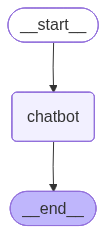

In [5]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [6]:
from langchain_community.tools.tavily_search import TavilySearchResults

# Tavily 검색 엔진을 도구로 정의
tool = TavilySearchResults(max_results=2)
tools = [tool]

# 호출 예시
tool.invoke("내일 대한민국 서울의 날씨는?")

C:\Users\Dohy\AppData\Local\Temp\ipykernel_9504\1638099478.py:4: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tool = TavilySearchResults(max_results=2)


[{'title': '서울특별시, 서울시, 대한민국 시간별 날씨 - AccuWeather',
  'url': 'https://www.accuweather.com/ko/kr/seoul/226081/hourly-weather-forecast/226081',
  'content': '쾌적함\n\nrain drop 0%\n\n약간 흐림\n\n체감수28°\n\n바람남동 9km/h\n\n대기질나쁨\n\n돌풍22km/h\n\n습도49%\n\n이슬점16° C\n\nAccuLumen Brightness Index™0 (어둡게)\n\n구름량49%\n\n가시거리16km\n\n운저9100m\n\n## 오후 9시\n\n26°\n\nRealFeel® 25°\n\n쾌적함\n\nrain drop 0%\n\n간헐적으로 흐림\n\n바람남동 7km/h\n\n대기질나쁨\n\n돌풍20km/h\n\n습도56%\n\n이슬점16° C\n\nAccuLumen Brightness Index™0 (어둡게)\n\n구름량51%\n\n가시거리16km\n\n운저9100m\n\n## 오후 10시\n\n24°\n\nRealFeel® 23°\n\n쾌적함\n\nrain drop 0%\n\n간헐적으로 흐림\n\n바람남동 7km/h\n\n대기질보통\n\n돌풍17km/h\n\n습도61%\n\n이슬점16° C\n\nAccuLumen Brightness Index™0 (어둡게)\n\n구름량66%\n\n가시거리16km\n\n운저9100m\n\n## 오후 11시\n\nRealFeel® 21°\n\n쾌적함\n\nrain drop 0%\n\n대체로 흐림\n\n바람동남동 7km/h\n\n대기질보통\n\n돌풍17km/h\n\n습도67%\n\n이슬점16° C\n\nAccuLumen Brightness Index™0 (어둡게)\n\n구름량82%\n\n가시거리16km\n\n운저9100m\n\n### 내일 ### 목요일 ### 10일\n\n전 세계\n\n### 허리케인 ### 악천후 기상 ### 레이더 및 지도 ### 동영상\n\n전 세계 아시아 

In [7]:
from langchain_core.messages import ToolMessage, BaseMessage, AIMessage
# 그래프 상태 정의
class State(TypedDict):
    messages: Annotated[list, add_messages]

# 그래프 정의
graph_builder = StateGraph(State)

llm = ChatOpenAI(model='gpt-4o-mini')
# llm에 Tavily 검색 엔진 도구 할당
llm_with_tools = llm.bind_tools(tools)

# 챗봇 함수 정의
def chatbot(state: State):
    return {"messages":[llm_with_tools.invoke(state['messages'])]}

# 그래프에 챗봇 노드 추가
graph_builder.add_node("chatbot", chatbot)

# 도구 노드를 사용할 클래스
class BasicToolNode:
    # 도구 노드에서 사용할 초기 파라미터 정의
    def __init__(self, tools:list)->None:
        self.tools_by_name = {tool.name: tool for tool in tools}

    # 도구 노드가 호출될 때의 행동 정의
    def __call__(self, inputs: dict):
        # 입력된 상태의 가장 마지막 메세지 획득
        if messages := inputs.get('messages',[]):
            message = messages[-1]
        else:
            raise ValueError("No Message found in input")
        
        # 메세지의 tool_calls에 도구 정보가 존재한다면 이를 활용해 도구 호출
        outputs=[]
        for tool_call in message.tool_calls:
            tool_result = self.tools_by_name[tool_call['name']].invoke(tool_call['args']) # args: 도구에 넣을 입력값

            # 도구 호출의 결과물을 ToolMessage로 정의하여 출력값에 저장
            outputs.append(ToolMessage(content=json.dumps(tool_result, ensure_ascii=False), name=tool_call['name'], tool_call_id=tool_call['id']))

        # 출력값을 상태값 형식에 맞춰 반환
        return {"messages":outputs}
    
# 도구 노드 정의
tool_node = BasicToolNode(tools=[tool])

# 도구 노드를 그래프에 추가
graph_builder.add_node("tools", tool_node)

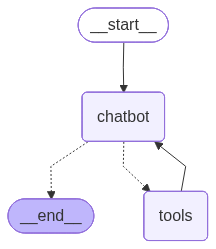

In [8]:
from typing import Literal
# 도구 노드 호출 여부를 결정하는 함수 정의
def route_tools(state: State,) -> Literal["tools","__end__"]:
    # 상태값의 가장 최근 메세지를 정의
    if isinstance(state,list):
        ai_message=state[-1]
    elif messages := state.get('messages',[]):
        ai_message = messages[-1]
    else:
        raise ValueError("No Messages found in input state to tool_edge: {state}")
    # 가장 최근 메세지에 tool_calls 속성이 있다면 tools 노드를, 아니라면 종료 지점을 반환
    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return "tools"
    return "__end__"

# Chatbot 노드에 조건부 엣지를 정의
graph_builder.add_conditional_edges("chatbot", route_tools, {"tools":"tools","__end__":"__end__"}) # __end__ = END

# 도구 노드와 챗봇 노드 연결
graph_builder.add_edge("tools","chatbot")

# 진입 지점으로 챗봇 노드 지정
graph_builder.add_edge(START, "chatbot")

graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [9]:
while True:
    user_input = input("User: ")
    print("User: ",user_input)
    if user_input.lower() in ['quit','q','exit']:
        print("Good bye!")
        break
    # 업데이트된 내용을 확인할 수 있는 그래프 스트리밍 정의
    events = graph.stream(input={"messages":[("user",user_input)]}, stream_mode="updates")
    # 그래프 이벤트 내의 메세지 출력
    for event in events:
        for value in event.values():
            if isinstance(value["messages"][-1], BaseMessage):
                print("Assistant: ", value['messages'][-1].content)

User:  안녕!
Assistant:  안녕하세요! 어떻게 도와드릴까요?
User:  부산 날씨 알려줘
Assistant:  
Assistant:  [{"title": "부산광역시, 부산시, 대한민국 시간별 날씨 | AccuWeather", "url": "https://www.accuweather.com/ko/kr/busan/222888/hourly-weather-forecast/222888", "content": "돌아가기 \n\n# 부산광역시, 부산시\n\n68°F  \n\n현재 위치 사용\n\n 68°\n\n결과를 찾을 수 없습니다.\n\n도시나 우편번호, 관심 지역을 검색해 보세요.\n\nPremium+ 가져오기\n\n사용자 계정 생성  무료 계정으로 확장된 일일 및 시간별 예보를 잠금 해제하세요.\n\n시작하기\n\n이미 계정이 있으신가요?  로그인\n\n설정\n\n 도움말 \n\n부산광역시, 부산시 날씨\n\n오늘 WinterCast 지역 {stormName} 추적기 시간별 10일 레이더 MinuteCast® 월간 대기질 건강 및 활동\n\n전 세계\n\n### 허리케인 ### 악천후 기상 ### 레이더 및 지도 ### 동영상\n\n오늘  ## 시간별  10일   레이더   MinuteCast®   월   대기질   건강 및 활동\n\n \n\n10일 전에 시간별 예보 보기\n\nPremium+ 구독을 활성화하세요\n\n## 오후 9시\n\n68°\n\nRealFeel® 66°\n\n쾌적함\n\nrain drop 54%\n\n소나기\n\n바람북동 8mi/h\n\n대기질보통\n\n돌풍22mi/h\n\n습도94%\n\n이슬점66° F\n\nAccuLumen Brightness Index™0 (어둡게)\n\n구름량100%\n\n가시거리4mi\n\n운저1600ft\n\n## 오후 10시\n\n68°\n\nRealFeel® 65°\n\n쾌적함\n\nrain drop 54%\n\n소나기\n\n바람북북동 8mi/h\n\n대기질보통\n\n돌풍20mi/h\n\n습

In [10]:
# 상태 저장
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import ToolNode, tools_condition

memory = MemorySaver()

class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

tool = TavilySearchResults(max_results=2)
tools = [tool]

llm = ChatOpenAI(model='gpt-4o-mini')
llm_with_tools = llm.bind_tools(tools)

def chatbot(staet:State):
    return {"messages":[llm_with_tools.invoke(staet['messages'])]}

graph_builder.add_node("chatbot",chatbot)

tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools",tool_node)

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition
)

graph_builder.add_edge("tools","chatbot")
graph_builder.add_edge(START,"chatbot")

# 체크포인터를 지정하여 그래프 컴파일
graph = graph_builder.compile(checkpointer=memory)

config = {"configurable":{"thread_id":{"1"}}} # 대화의 key로 사용될 thread_id 정의

user_input = "안녕! 내 이름은 페이커야."
events = graph.stream({"messages":[("user",user_input)]}, config, stream_mode='values')

for event in events:
    event['messages'][-1].pretty_print()

================================ Human Message =================================

안녕! 내 이름은 페이커야.
================================== Ai Message ==================================

안녕하세요, 페이커님! 반갑습니다. 어떻게 도와드릴까요?


In [11]:
user_input = "내 이름을 기억하니?"
events = graph.stream({"messages":[("user",user_input)]}, config, stream_mode='values')

for event in events:
    event['messages'][-1].pretty_print()

================================ Human Message =================================

내 이름을 기억하니?
================================== Ai Message ==================================

네, 페이커님! 이름을 잘 기억하고 있습니다. 무엇을 도와드릴까요?


In [12]:
events = graph.stream(
    {'messages':[("user",user_input)]}, {'configurable':{"thread_id":"2"}}, stream_mode='values'
)

for event in events:
    event['messages'][-1].pretty_print()

================================ Human Message =================================

내 이름을 기억하니?
================================== Ai Message ==================================

죄송하지만, 저는 사용자의 이름이나 개인 정보를 기억할 수 없습니다. 하지만 도와드릴 수 있는 다른 질문이나 요청이 있다면 말씀해 주세요!


In [13]:
snapshot = graph.get_state(config)
print(snapshot)

StateSnapshot(values={'messages': [HumanMessage(content='안녕! 내 이름은 페이커야.', additional_kwargs={}, response_metadata={}, id='14e36e37-6e34-45b4-b9fc-321b20fbbad5'), AIMessage(content='안녕하세요, 페이커님! 반갑습니다. 어떻게 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 90, 'total_tokens': 110, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_795bd00303', 'id': 'chatcmpl-DuPfeSrpNgJgAcAZKSGB5XeffXWEs', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019efb96-b61d-71d3-91ad-0232794aeb4a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 90, 'output_tokens': 20, 'total_tokens': 110, 'input_token_details': {'audio': 0, 'cache_r

In [14]:
# Human-in-the-loop
graph = graph_builder.compile(checkpointer=memory, interrupt_before=["tools"])

user_input='지금 서울 날씨 어때?'
config = {"configurable":{"thread_id":"2"}}
events = graph.stream(
    {'messages':[("user",user_input)]}, config, stream_mode='values'
)
for event in events:
    if 'messages' in event:
        event['messages'][-1].pretty_print()

================================ Human Message =================================

지금 서울 날씨 어때?
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (call_0F8ndnmaj0cjRBADMVeHVoRA)
 Call ID: call_0F8ndnmaj0cjRBADMVeHVoRA
  Args:
    query: 서울 날씨


In [15]:
snapshot = graph.get_state(config)
print(snapshot.next)

('tools',)


In [16]:
# 임의의 응답 강제로 입력
from langchain_core.messages import AIMessage

# 최근 메세지
existing_message = snapshot.values['messages'][-1]

# 최근 메세지의 ID
existing_message_id = existing_message.tool_calls[0]['id']

# 강제할 응답
answer = "서울의 날씨는 매우 맑아요."

# 강제할 응답을 포함한 메세지 상태 정의
new_messages=[
    ToolMessage(content=answer, tool_call_id=existing_message_id),
    AIMessage(content=answer)
]

# 그래프 상태를 새로 작성한 메세지 상태로 변경
graph.update_state(config,{"messages":new_messages})

print('\n\nLast 2 messages;')
print(graph.get_state(config).values['messages'][-2:])



Last 2 messages;
[ToolMessage(content='서울의 날씨는 매우 맑아요.', id='88f783a7-eff4-4347-bd8c-8e14c521ea7a', tool_call_id='call_0F8ndnmaj0cjRBADMVeHVoRA'), AIMessage(content='서울의 날씨는 매우 맑아요.', additional_kwargs={}, response_metadata={}, id='0ba408eb-c7a2-43e2-835d-4063a5c67bb4', tool_calls=[], invalid_tool_calls=[])]


In [17]:
# 기존 메세지 수정
user_input = "지금 서울 날씨 어때?"
config = {"configurable": {"thread_id":"3"}}
events = graph.stream(
    {"messages":[("user",user_input)]}, config, stream_mode='values'
)

for event in events:
    if 'messages' in event:
        event['messages'][-1].pretty_print()



================================ Human Message =================================

지금 서울 날씨 어때?
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (call_4hQgt6RthmuM5udXWzVUI0hN)
 Call ID: call_4hQgt6RthmuM5udXWzVUI0hN
  Args:
    query: current weather in Seoul


In [18]:
snapshot = graph.get_state(config)
existing_message = snapshot.values['messages'][-1]
new_tool_call = existing_message.tool_calls[0].copy()
new_tool_call['args']['query'] = "지금 부산 날씨는 어때?"
new_message = AIMessage(
    content=existing_message.content,
    tool_calls=[new_tool_call],
    id=existing_message.id
)

graph.update_state(config, {'messages':[new_message]})

{'configurable': {'thread_id': '3',
  'checkpoint_ns': '',
  'checkpoint_id': '1f17015c-fb45-6863-8002-b80960d3fb14'}}

In [19]:
print('\n\nLast 2 Messages;')
print(graph.get_state(config).values['messages'][-2:])



Last 2 Messages;
[HumanMessage(content='지금 서울 날씨 어때?', additional_kwargs={}, response_metadata={}, id='6481e448-8f14-4729-917b-d018b38629f2'), AIMessage(content='', additional_kwargs={}, response_metadata={}, id='lc_run--019efb96-ffbd-7323-b59f-2b4747b281af-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': '지금 부산 날씨는 어때?'}, 'id': 'call_4hQgt6RthmuM5udXWzVUI0hN', 'type': 'tool_call'}], invalid_tool_calls=[])]


In [20]:
events = graph.stream(None, config, stream_mode='values')

for event in events:
    if 'messages' in event:
        event['messages'][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (call_4hQgt6RthmuM5udXWzVUI0hN)
 Call ID: call_4hQgt6RthmuM5udXWzVUI0hN
  Args:
    query: 지금 부산 날씨는 어때?
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "날씨 부산 오늘 시간별 | freemeteo.kr", "url": "https://freemeteo.kr/weather/busan/hourly-forecast/today?gid=9035612&language=korean&country=south-korea", "content": "오늘시간별15 일메테오그램라이브 위성 이미지지도일일 기록\n\n# 부산오늘 시간별 날씨\n\n21°C\n\n지금\n\n## 시간별 날씨 오늘 - 6월 24\n\nicon-forecast-5\n\n비 올 확률\n\n35 km/h\n\n0.3mm\n\nHumidity86%\n\nPressure1007.7mb\n\nwind-chill-temperature21°\n\n비 올 확률\n\nHumidity86%\n\nPressure1007.7mb\n\nwind-chill-temperature21°\n\nprecipitation0.3mm\n\n15:00\n\nicon-forecast-5\n\n비 올 확률\n\n20°\n\n32 km/h\n\n0.6mm\n\nHumidity86%\n\nPressure1006.6mb\n\nwind-chill-temperature20°\n\n비 올 확률\n\nHumidity86%\n\nPressure1006.6mb\n\nwind-chill-tempe

In [21]:
events = graph.stream(None, config, stream_mode='values')

for event in events:
    if 'messages' in event:
        event['messages'][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (call_u5yOczQgbMeiryTbiPRNK3Xm)
 Call ID: call_u5yOczQgbMeiryTbiPRNK3Xm
  Args:
    query: 지금 서울 날씨
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "서울 실시간 날씨 정보 | 서울 공식 관광정보 웹사이트", "url": "https://korean.visitseoul.net/weather", "content": "SEOUL GOODS\n\n흐림\n\n검색 영역; \"검색 영역 열기\")\n\n### 나의찜하기\n\n찜하기는 관심 있는 여행 정보를 저장하여 서울의 주요 지역별로 탐색할 수 있는 기능입니다.\n\n나의 찜한 목록 바로가기\n\n한국어\n\n다국어 메뉴 \n\n 한국어\n English\n 日本語\n 简体中文\n 繁體中文\n русскийязыкbeta\n Malaybeta\n\nFamily Site\n\nFamily Site; \"패밀리사이트 메뉴 열기\") \n\n 파트너스\n STO 소개\n 의료관광\n 서울관광 아카이브\n 서울관광플라자\n 디스커버서울패스\n 서울스테이\n 다누림관광\n 서울등산관광\n 서울컨벤션뷰로\n 서울컬쳐라운지\n Visit Seoul API\n SEOUL BLEISURE\n 서울미식주간\n\n전체보기메뉴 열기버튼\n\n전체보기메뉴 열기버튼\n\n## visitseoul.net\n\n### 검색순위\n\n### 나의찜하기\n\n찜하기는 관심 있는 여행 정보를 저장하여 서울의 주요 지역별로 탐색할 수 있는 기능입니다.\n\n나의 찜한 목록 바로가기\n\

In [23]:
# 자체교정-RAG(Corrective-RAG)
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import Chroma
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_core.output_parsers import StrOutputParser
urls = [
    "https://google.github.io/styleguide/pyguide.html",
    "https://google.github.io/styleguide/javaguide.html",
    "https://google.github.io/styleguide/jsguide.html",
]

docs = [WebBaseLoader(url).load() for url in urls]
#print(docs[0])
#print(len(docs))
docs_list = [item for sublist in docs for item in sublist]
#print(docs_list[0])
#print(len(docs_list))

text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(chunk_size=250, chunk_overlap=0) # 크롤링한 문서의 내용을 빠르게 검색하려면 텍스트를 분할하여 저장해야 됨. 긴 문서 전체에서 원하는 키워드를 검색하는 것보다 분할된 작은 텍스트에서 키워드를 검색하는 것이 훨씬 빠르고 결과를 도출하기 쉬움
docs_splits = text_splitter.split_documents(docs_list)

vectorstore = Chroma.from_documents(
    documents=docs_splits,
    collection_name='rag-chroma',
    embedding=OpenAIEmbeddings()
)

retriever = vectorstore.as_retriever()

# 문서와 질문의 연관성을 평가하기 위한 데이터 모델 정의
class GradeDocuments(BaseModel):
    binary_score:str = Field(description="문서와 질문의 연관성 여부. (예 or 아니요)")

# 연관성 평가를 위한 LLM
llm= ChatOpenAI(model='gpt-4o-mini', temperature=0)
structured_llm_grader = llm.with_structured_output(GradeDocuments)

# LLM이 사용자의 질문에 대해 문서의 연관성을 평가할 수 있도록 지시하는 프롬프트
system = """
당신은  사용자의 질문에 대해 검색된 문서의 관련성을 평가하는 전문가입니다.
문서에 질문과 관련된 키워드나 의미가 담겨 있으면, 해당 문서를 ‘관련 있음’으로 평가하세요.
문서가 질문과 관련이 있는지 여부를 ‘예’ 또는 ‘아니오’로 표시해 주세요.
"""

grade_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "검색된 문서: \n\n {document} \n\n 사용자 질문: {question}"),
    ]
)

retrieval_grader = grade_prompt | structured_llm_grader

query = "파이썬 코드 작성 가이드"

# 연관 문서 검색
docs= retriever.invoke(query)
doc_txt=docs[1].page_content # 아무 인덱스를 써도 무방

# 검색된 문서의 연관성 평가
print(retrieval_grader.invoke({"question":query, "document":doc_txt}))

binary_score='예'


In [24]:
# LLM이 제공된 문맥을 바탕으로 답변할 수 있도록 지시하는 프롬프트 정의
system = """
당신은 질문에 답변하는 업무를 돕는 도우미입니다.
제공된 문맥을 바탕으로 질문에 답변하세요. 만약 답을 모르면 모른다고 말하세요.
세 문장을 넘지 않도록 답변을 간결하게 작성하세요.
"""

prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "질문: {question} \n문맥: {context} \n답변:"),
    ]
)

# 검색된 문서들을 한 문자열로 합침
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)


rag_chain = prompt | llm | StrOutputParser()

generation = rag_chain.invoke({"context": format_docs(docs), "question":query})
print(generation)

파이썬 코드 작성 가이드는 Google에서 사용하는 파이썬 프로그래밍의 규칙과 스타일을 정리한 것입니다. 코드 포맷팅을 위해 Vim과 Emacs에 대한 설정 파일이 제공되며, Black이나 Pyink 같은 자동 포맷터를 사용하는 것이 권장됩니다. 또한, pylint를 사용하여 코드의 버그와 스타일 문제를 찾아내는 것이 중요합니다.


In [25]:
# 쿼리 재작성
# LLM이 입력된 질문을 웹 검색에 적합한 형태로 변형하도록 지시하는 프롬프트
system = """
당신은 입력된 질문을 변형하여 웹 검색에 최적화된 형태로 만드는 질문생성기입니다.
입력된 질문을 보고 그 이면에 있는 의미나 의도를 파악해주세요.
"""

re_write_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        (
            "human", "질문: \n\n {question} \n 더 나은 질문으로 바꿔주세요.",
        ),
    ]
)

question_rewriter = re_write_prompt | llm | StrOutputParser()
query = "C++ 깔끔하게 짜고 싶다"
question_rewriter.invoke({"question":query})

'C++ 코드를 깔끔하고 효율적으로 작성하는 방법은 무엇인가요?'

In [26]:
# 웹 검색하기
from langchain_community.tools.tavily_search import TavilySearchResults
web_search_tool = TavilySearchResults(k=3)

In [27]:
# 그래프에서 사용할 상태값 정의
from typing import List
from typing_extensions import TypedDict

class GraphState(TypedDict):
    question: str # 사용자 질문 혹은 웹 검색을 위해 재작성된 쿼리
    generation: str # LLM이 생성한 답변
    web_search: str # 웹 검색 여부를 나타내는 상태
    documents: List[str] # 검색된 문서 리스트

    

In [28]:
# 노드들이 수행할 행동에 대한 메소드
from langchain_core.documents import Document

def retrieve(state):
    """
    문서를 검색합니다

    Args:
        state (dict): 현재 그래프의 상태

    Returns:
        state (dict): 검색된 문서를 포함한 새로운 상태
    """

    print("---검색---")
    question = state['question']

    documents = retriever.invoke(question)
    return {'documents':documents,'question':question}

def generate(state):
    """
    답변을 생성합니다

    Args:
        state (dict): 현재 그래프의 상태
    
    Returns:
        state (dict): LLM이 생성한 답변을 포함한 새로운 상태
    """

    print("---생성---")
    question = state['question']
    documents = state['documents']

    generation = rag_chain.invoke({"context":documents, "question":question})
    return {'documents':documents, 'question':question, 'generation':generation}

def grade_documents(state):
    """
    검색된 문서가 질문과 연관이 있는지 평가합니다

    Args:
        state (dict): 현재 그래프의 상태

    Returns:
        state (dict): 연관이 있다고 판단된 문서가 업데이트된 상태
    """

    print('---문서와 질문의 연관성 평가---')
    question=state['question']
    documents=state['documents']

    filtered_docs = []
    web_search = '아니오'
    for d in documents:
        score = retrieval_grader.invoke(
            {"question":question, "document":d.page_content}
        )
        grade = score.binary_score
        if grade== "예":
            print("---평가: 연관 문서---")
            filtered_docs.append(d)
        else:
            print("---평가: 연관 없는 문서---")
            web_search="예"
            continue
    return {'documents':filtered_docs, "question":question, 'web_search':web_search}


def transform_query(state):
    """
    질문을 더 적합한 형태로 변환합니다

    Args:
        state (dict): 현재 그래프의 상태

    Returns:
        state (dict): 변환된 질문이 업데이트된 상태
    """

    print("---질문 변환---")
    question = state['question']
    documents = state['documents']

    better_question = question_rewriter.invoke({'question':question})
    return {'documents':documents, "question":better_question}

def web_search(state):
    """
    웹 검색을 수행합니다

    Args:
        state (dict): 현재 그래프의 상태

    Returns:
        state (dict): 웹 검색 결과가 업데이트된 상태
    """

    print('---웹 검색---')
    question = state['question']
    documents = state['documents']

    docs = web_search_tool.invoke({"query":question})
    web_results = "\n".join([d['content'] for d in docs])
    web_results = Document(page_content=web_results)
    documents.append(web_results)

    return {'documents':documents, "question":question}

# 각 노드를 연결할 엣지에 대한 메소드
def decide_to_generate(state):
    """
    답변을 생성할지, 질문을 재생성할지 결정합니다

    Args:
        state (dict): 현재 그래프의 상태

    Returns:
        str: 다음에 호출할 노드
    """

    print("---문서 검토---")
    web_search = state['web_search']

    if web_search == "예":
        print("---연관 문서가 없음. 질문을 변환합니다")
        return "transform_query"
    else:
        print("---연관 문서가 있음. 답변을 생성합니다")
        return "generate"
    


In [29]:
#  Corrective-RAG 기능을 수행하는 그래프
from langgraph.graph import StateGraph, START, END

workflow = StateGraph(GraphState)

# 노드 정의
workflow.add_node("retrieve",retrieve)
workflow.add_node("grade_documents", grade_documents)
workflow.add_node("generate", generate)
workflow.add_node("transform_query", transform_query)
workflow.add_node("web_search_node", web_search)

# 그래프 정의
workflow.add_edge(START,"retrieve")
workflow.add_edge("retrieve","grade_documents")
workflow.add_conditional_edges("grade_documents", decide_to_generate, {"transform_query":"transform_query","generate":"generate"}) # tools_condition
workflow.add_edge("transform_query","web_search_node")
workflow.add_edge("web_search_node","generate")
workflow.add_edge("generate",END)

# 그래프 컴파일
app = workflow.compile()

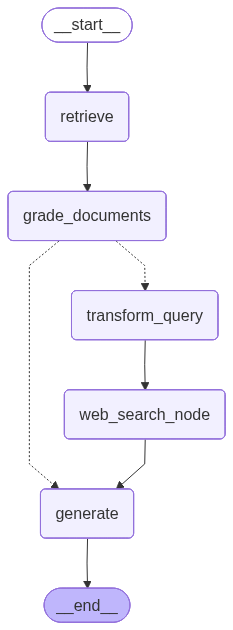

In [30]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [31]:
from pprint import pprint

inputs = {"question":"구글의 코드 작성 가이드"}
for output in app.stream(inputs):
    for key,value in output.items():
        pprint(f"Node '{key}': ")

pprint(value['generation'])

---검색---
"Node 'retrieve': "
---문서와 질문의 연관성 평가---
---평가: 연관 문서---
---평가: 연관 문서---
---평가: 연관 문서---
---평가: 연관 문서---
---문서 검토---
---연관 문서가 있음. 답변을 생성합니다
"Node 'grade_documents': "
---생성---
"Node 'generate': "
('구글의 JavaScript 코드 작성 가이드는 더 이상 업데이트되지 않으며, TypeScript로의 이전을 권장합니다. 이 가이드는 '
 'JavaScript 소스 코드의 코딩 표준을 정의하며, 주로 강제 규칙에 중점을 두고 있습니다. 자세한 내용은 [구글 JavaScript '
 '스타일 가이드](https://google.github.io/styleguide/jsguide.html)에서 확인할 수 있습니다.')


In [32]:
inputs = {'question':"C++ 깔끔하게 짜고 싶다"}
for output in app.stream(inputs):
    for key,value in output.items():
        pprint(f"Node '{key}': ")

pprint(value['generation'])

---검색---
"Node 'retrieve': "
---문서와 질문의 연관성 평가---
---평가: 연관 없는 문서---
---평가: 연관 없는 문서---
---평가: 연관 문서---
---평가: 연관 문서---
---문서 검토---
---연관 문서가 없음. 질문을 변환합니다
"Node 'grade_documents': "
---질문 변환---
"Node 'transform_query': "
---웹 검색---
"Node 'web_search_node': "
---생성---
"Node 'generate': "
('C++ 코드를 깔끔하고 효율적으로 작성하려면, 명확한 명명 규칙을 따르고, 코드를 작은 단위로 분할하여 가독성을 높여야 합니다. 또한, '
 '주석은 필요한 경우에만 사용하고, 코드 자체가 이해하기 쉬운 구조로 작성되어야 합니다. 마지막으로, RAII와 스마트 포인터를 활용하여 '
 '메모리 관리를 자동화하고, 성능을 고려한 최적화를 진행하는 것이 중요합니다.')


In [49]:
# 코드 어시스트 챗봇

from bs4 import BeautifulSoup as Soup
from langchain_community.document_loaders.recursive_url_loader import RecursiveUrlLoader
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI

# 크롤링할 URL
url = "https://python.langchain.com/v0.2/docs/concepts/#langchain-expression-language-lcel"
loader = RecursiveUrlLoader(
    url=url, max_depth=20, extractor=lambda x: Soup(x, "html.parser").text
)
docs = loader.load()

d_sorted = sorted(docs, key=lambda x: x.metadata["source"])
d_reversed = list(reversed(d_sorted))

concatenated_content = "\n\n\n --- \n\n\n".join(
    [doc.page_content for doc in d_reversed]
)

system = """
당신은 LCEL(LangChain Expression Language) 전문가인 코딩 어시스턴트입니다.
다음은 필요한 LCEL 문서 전문입니다:
-------
{context}
-------
위에 제공된 문서를 기반으로 사용자 질문에 답변하세요.
제공하는 코드는 실행 가능해야 하며, 필요한 모든 import 문과 변수들이 정의되어 있어야 합니다.
답변을 다음과 같은 구조로 작성하세요:
1. prefix : 문제와 접근 방식에 대한 설명
2. imports : 코드 블록 import 문
3. code : import 문을 제외한 코드 블록
4. description : 질문에 대한 코드 스키마

다음은 사용자 질문입니다:
"""

code_gen_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("placeholder", "{messages}"),
    ]
)

class code(BaseModel):
    prefix: str = Field(description="문제와 접근 방식에 대한 설명")
    imports: str = Field(description="코드 블록 import 문")
    code: str = Field(description="import 문을 제외한 코드 블록")
    description: str = Field(description="질문에 대한 코드 스키마")


llm = ChatOpenAI(temperature=0, model="gpt-4o-mini")
code_gen_chain = code_gen_prompt | llm.with_structured_output(code)

query = "LCEL로 RAG 체인을 어떻게 만들어?"
solution = code_gen_chain.invoke({"context":concatenated_content, "messages":[("user",query)]})
print(solution)

prefix='이 코드는 LangChain을 사용하여 RAG(정보 검색 기반 생성) 체인을 만드는 방법을 보여줍니다. RAG 체인은 정보 검색과 생성 모델을 결합하여 사용자가 질문할 때 관련 정보를 검색하고, 그 정보를 바탕으로 응답을 생성합니다. 이 예제에서는 OpenAI의 GPT 모델과 함께 사용할 수 있는 간단한 RAG 체인을 설정합니다.' imports='from langchain.chains import RetrievalQA\nfrom langchain.llms import OpenAI\nfrom langchain.retrievers import VectorStoreRetriever\nfrom langchain.vectorstores import FAISS\nimport numpy as np\n\n# 예시 문서 데이터\ndocuments = [\n    "LangChain은 LLM을 위한 프레임워크입니다.",\n    "RAG는 정보 검색과 생성 모델을 결합한 것입니다.",\n    "OpenAI의 GPT 모델은 자연어 처리에 강력합니다."\n]\n\n# 문서 벡터화 및 저장소 생성\nvector_store = FAISS.from_texts(documents, np.random.rand(len(documents), 768))\nretriever = VectorStoreRetriever(vector_store=vector_store)' code='# LLM과 검색기를 사용하여 RAG 체인 생성\nllm = OpenAI(model_name="gpt-3.5-turbo")\nrag_chain = RetrievalQA(llm=llm, retriever=retriever)\n\n# 질문에 대한 응답 생성\nquery = "LangChain이란 무엇인가요?"\nresponse = rag_chain.run(query)\nprint(response)' description='이 코드는 LangChain을 사용하여 RAG 체인을 설정하는 방법을 보여줍니다. 먼저, 문서

In [45]:
class GraphState(TypedDict):
    error: str # 테스트 오류가 발생했는지 여부
    messages: List # 사용자 질문, 오류 메세지, 이유 등을 포함하는 메세지 목록
    generation: str # 생성된 코드
    iterations: int # 시도 횟수

# 노드의 행동을 정의하는 메소드들
def generate(state: GraphState):
    """
    코드를 생성합니다

    Args:
        state (dict): 현재 그래프의 상태
    
    Returns:
        state (dict): 생성한 코드가 업데이트된 상태
    """

    print("---코드 샏성---")
    messages = state['messages']
    iterations = state['iterations']
    error = state.get("error",'no')

    if error == 'yes':
        messages +=[
            (
                "user",
                "다시 시도해보세요. 출력 결과를 prefix, imports, code block으로 구조화하기 이해 코드 도구를 호출하세요:",
            )
        ]
    code_solution = code_gen_chain.invoke(
        {"context": concatenated_content, "messages":messages}
    )
    messages += [
        ("assistant",
         f"{code_solution.prefix} \n Imports: {code_solution.imports} \n Code:{code_solution.code}",)
    ]

    iterations = iterations + 1
    return {"generation":code_solution, "messages":messages, "iterations":iterations}

def code_check(state: GraphState):
    """
    코드 검사

    Args:
        state (dict): 현재 그래프의 상태

    Returns:
        state (dict): 오류 여부가 업데이트된 상태
    """

    print("---코드 검사---")
    messages = state['messages']
    code_solution = state['generation']
    iterations = state['iterations']

    imports = code_solution.imports
    code = code_solution.code

    try:
        exec(imports)
    except Exception as e:
        print('---import 체크: 실패---')
        error_message = [("user",f"당신의 코드는 import 테스트를 실패했습니다: {e}")]
        messages += error_message
        return {
            'generation':code_solution,
            'messages':messages,
            'iterations':iterations,
            'error':'yes'
        }
    try:
        exec(imports + '\n' + code)
    except Exception as e:
        print("---code block 체크: 실패---")
        error_message =[("user",f"당신의 코드는 실행 테스트를 실패했습니다: {e}")]
        messages += error_message
        return {
            "generation":code_solution,
            "messages":messages,
            "iterations":iterations,
            "error":"yes",
        }
    
    print("---오류 없음---")
    return{
        "generation":code_solution,
        "messages":messages,
        "iterations":iterations,
        "error":"no",
    }

def reflect(state: GraphState):
    """
    오류 반영

    Args:
        state (dict): 현재 그래프 상태

    Returns:
        state (dict): 생성된 코드가 추가된 상태
    """

    print("---코드 솔루션 생성---")
    messages = state['messages']
    iterations = state['iterations']
    code_solution = state['generation']

    reflections = code_gen_chain.invoke(
        {"context":concatenated_content, "messages":messages}
    )
    messages += [("assistant",f"여기 오류를 반영한 코드입니다: {reflections}")]
    return {
        "generation":code_solution,
        "messages":messages,
        "iterations":iterations
    }

# 엣지 메소드 구현
flag = "Do not reflect"

def decide_to_finish(state: GraphState):
    """
    종료 여부를 결정합니다

    Args:
        state (dict): 현재 그래프의 상태

    Returns:
        str: 다음에 호출할 노드
    """

    error = state['error']
    iterations = state['iterations']

    if error=="no" or iterations == 3:
        print("---종료---")
        return 'end'
    else:
        print('---재시도---')
        if flag is True:
            return "reflect"
        else:
            return "generate"
        
# 그래프 구성
workflow = StateGraph(GraphState)

# 노드 정의
workflow.add_node("generate",generate)
workflow.add_node("check_code", code_check)
workflow.add_node("reflect", reflect)

# 그래프 정의
workflow.add_edge(START,"generate")
workflow.add_edge("generate","check_code")
workflow.add_conditional_edges(
    "check_code",
    decide_to_finish,
    {
        'end':END,
        'reflect':'reflect',
        'generate':'generate'
    }
)
workflow.add_edge("reflect", 'generate')

app = workflow.compile()

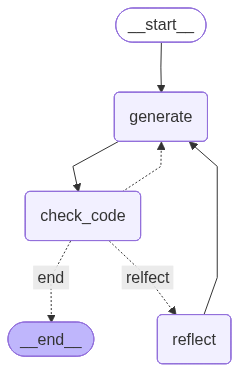

In [43]:
display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
query = "문자열을 runnable 객체에 직접 전달하고, 이를 사용하여 내 프롬프트에 필요한 입력을 구성하려면 어떻게 해야 하나요?"
app.invoke({"messages":[("user",query)], "iterations":0})
# URL에 있는 LangChain 버전이 0.2라 안돌아감

---코드 샏성---
---코드 검사---
---import 체크: 실패---
---재시도---
---코드 샏성---
---코드 검사---
---import 체크: 실패---
---재시도---
---코드 샏성---
---코드 검사---
---import 체크: 실패---
---종료---


{'error': 'yes',
 'messages': [('user',
   '문자열을 runnable 객체에 직접 전달하고, 이를 사용하여 내 프롬프트에 필요한 입력을 구성하려면 어떻게 해야 하나요?'),
  ('assistant',
   '이 문제는 문자열을 runnable 객체에 직접 전달하여 프롬프트에 필요한 입력을 구성하는 방법에 대한 것입니다. LangChain의 runnable 객체를 사용하면 다양한 입력을 처리하고, 이를 통해 모델에 전달할 수 있는 형식으로 변환할 수 있습니다. 이 예제에서는 문자열을 runnable 객체로 변환하고, 이를 사용하여 프롬프트를 구성하는 방법을 보여줍니다. \n Imports: from langchain.runnables import RunnableLambda\nfrom langchain.prompts import PromptTemplate \n Code:# 문자열을 runnable 객체로 변환하는 함수 정의\nstring_to_runnable = RunnableLambda(lambda x: f"Hello, {x}!")\n\n# runnable 객체를 사용하여 프롬프트 구성\nname = "World"\nresult = string_to_runnable.invoke(name)\nprint(result)'),
  ('user',
   "당신의 코드는 import 테스트를 실패했습니다: No module named 'langchain.runnables'"),
  ('user',
   '다시 시도해보세요. 출력 결과를 prefix, imports, code block으로 구조화하기 이해 코드 도구를 호출하세요:'),
  ('assistant',
   '이 문제는 문자열을 runnable 객체에 직접 전달하여 프롬프트에 필요한 입력을 구성하는 방법에 대한 것입니다. LangChain의 runnable 객체를 사용하면 다양한 입력을 처리하고, 이를 통해 모델에 전달할 수 있는 형식으로 변환할 수 있습니다. 이 예제에서는 문